### 1. Import Libraries

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### 2. Ideal High Pass Filter Function

In [4]:
def ideal_highpass_filter(shape, cutoff_frequency):
    """Creates an ideal high-pass filter."""
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    mask = np.ones((rows, cols), np.uint8)
    cv2.circle(mask, (ccol, crow), cutoff_frequency, 0, -1)

    return mask

### 3. Butterworth High Pass Filter

In [5]:
def butterworth_highpass_filter(shape, cutoff_frequency, order=2):
    """Creates a Butterworth high-pass filter."""
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    mask = np.zeros((rows, cols), np.float32)

    for i in range(rows):
        for j in range(cols):
            dist = np.sqrt((i - crow)**2 + (j - ccol)**2)
            mask[i, j] = 1 / (1 + (cutoff_frequency / (dist + 1e-5))**(2 * order))

    return mask

### 4. Gaussian High Pass Filter

In [6]:
def gaussian_highpass_filter(shape, cutoff_frequency):
    """Creates a Gaussian high-pass filter."""
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    mask = np.zeros((rows, cols), np.float32)

    for i in range(rows):
        for j in range(cols):
            dist = np.sqrt((i - crow)**2 + (j - ccol)**2)
            mask[i, j] = 1 - np.exp(-(dist**2) / (2 * (cutoff_frequency**2)))

    return mask

### Laod Image , Compute Fourier Transform, Magnitude Spectrum, Create Filters, Apply Filters, Inverse Shift, Inverse Fourier Transform

In [7]:
## 5.Load Image
image = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)

## 6.Compute Fourier Transform (Converts image → frequency domain.)
dft = cv2.dft(np.float32(image), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

## 7. Magnitude Spectrum (Log scaling for visualization.)
magnitude = cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1])
magnitude_spectrum = 20 * np.log(magnitude + 1)

## 8. Create Filters
cutoff_frequency = 30

ideal_mask = ideal_highpass_filter(image.shape, cutoff_frequency)
butterworth_mask = butterworth_highpass_filter(image.shape, cutoff_frequency)
gaussian_mask = gaussian_highpass_filter(image.shape, cutoff_frequency)

## 9. Apply Filters
filtered_ideal = dft_shift * ideal_mask[:, :, np.newaxis]
filtered_butterworth = dft_shift * butterworth_mask[:, :, np.newaxis]
filtered_gaussian = dft_shift * gaussian_mask[:, :, np.newaxis]

## 10. Inverse Shift
ideal_ishift = np.fft.ifftshift(filtered_ideal)
butterworth_ishift = np.fft.ifftshift(filtered_butterworth)
gaussian_ishift = np.fft.ifftshift(filtered_gaussian)

## 11. Inverse Fourier Transform
ideal_back = cv2.idft(ideal_ishift)
butterworth_back = cv2.idft(butterworth_ishift)
gaussian_back = cv2.idft(gaussian_ishift)

### Reconstruct Images, Normalize Images,

In [8]:
## 12. Reconstruct Images
ideal_image = cv2.magnitude(ideal_back[:, :, 0], ideal_back[:, :, 1])
butterworth_image = cv2.magnitude(butterworth_back[:, :, 0], butterworth_back[:, :, 1])
gaussian_image = cv2.magnitude(gaussian_back[:, :, 0], gaussian_back[:, :, 1])

## 13. Normalize Images
ideal_image = cv2.normalize(ideal_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
butterworth_image = cv2.normalize(butterworth_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
gaussian_image = cv2.normalize(gaussian_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

### 14. Display Results

(-0.5, 1299.5, 866.5, -0.5)

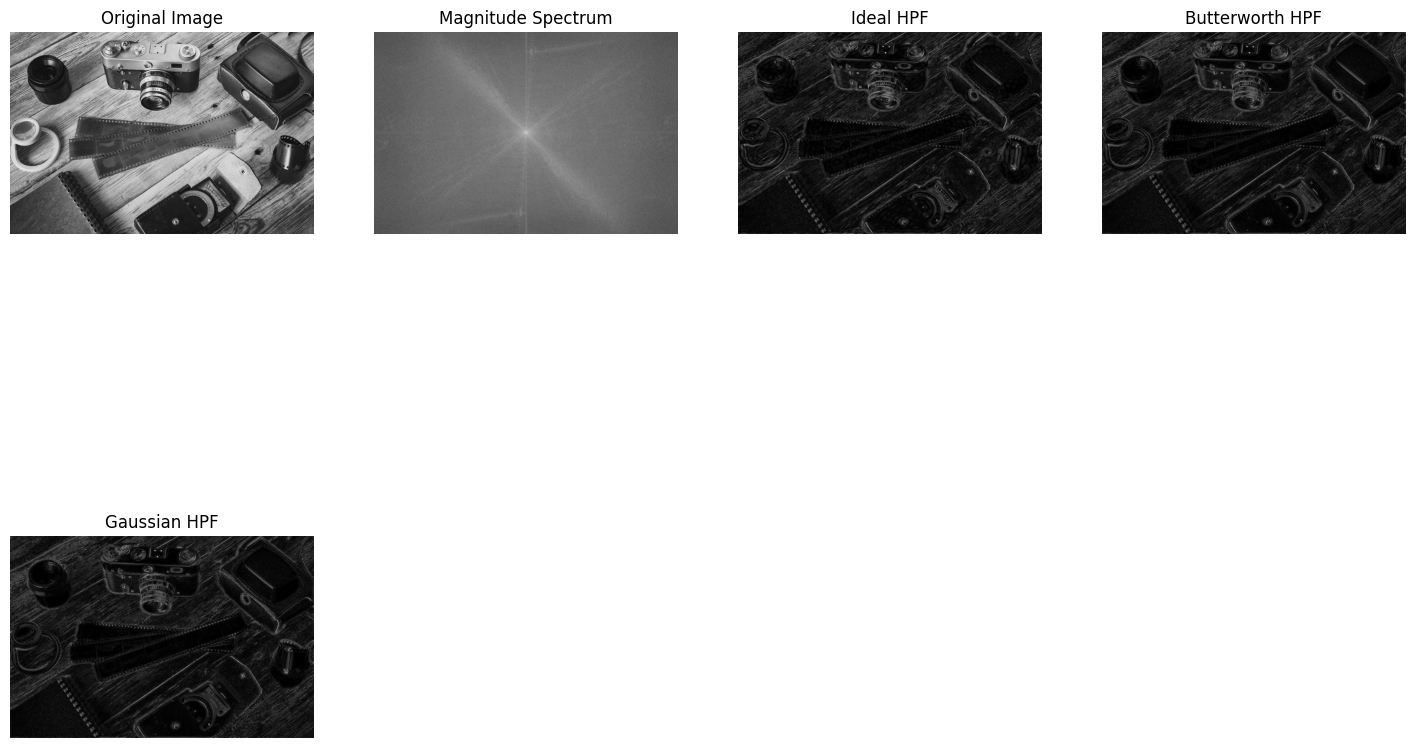

In [9]:
plt.figure(figsize=(18, 12))

plt.subplot(2,4,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(ideal_image, cmap='gray')
plt.title('Ideal HPF')
plt.axis('off')

plt.subplot(2,4,4)
plt.imshow(butterworth_image, cmap='gray')
plt.title('Butterworth HPF')
plt.axis('off')

plt.subplot(2,4,5)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Gaussian HPF')
plt.axis('off')

### 15. 3D Transfer Function Plots

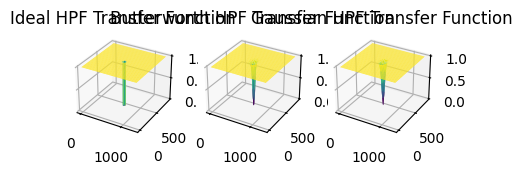

In [10]:
X, Y = np.meshgrid(np.arange(ideal_mask.shape[1]), np.arange(ideal_mask.shape[0]))

ax1 = plt.subplot(2,4,6, projection='3d')
ax1.plot_surface(X, Y, ideal_mask, cmap='viridis')
ax1.set_title('Ideal HPF Transfer Function')

ax2 = plt.subplot(2,4,7, projection='3d')
ax2.plot_surface(X, Y, butterworth_mask, cmap='viridis')
ax2.set_title('Butterworth HPF Transfer Function')

ax3 = plt.subplot(2,4,8, projection='3d')
ax3.plot_surface(X, Y, gaussian_mask, cmap='viridis')
ax3.set_title('Gaussian HPF Transfer Function')

plt.show()